# Descomposición STL

En este notebook vamos a descomponer la serie para cuantificar estacionalidad, aislar tendencia si es que hay y ver como se comporta el residuo, que será un dato importante para evaluar el comportamiento de la serie con el precio regular y las promociones.

Tal cómo se determinó en el primer notebook, vamos a trabajar solo con un producto y eliminar las primeras fases de la serie.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

## Carga de datos

In [5]:
pepsi = pd.read_parquet('../data/processed/pepsi_2l.parquet')

print(pepsi.shape)
print(pepsi['start'].min(), ';',  pepsi['start'].max())
print(f'Tiendas: {pepsi["STORE"].nunique()}')

(31751, 15)
1989-09-14 00:00:00 ; 1997-05-01 00:00:00
Tiendas: 93


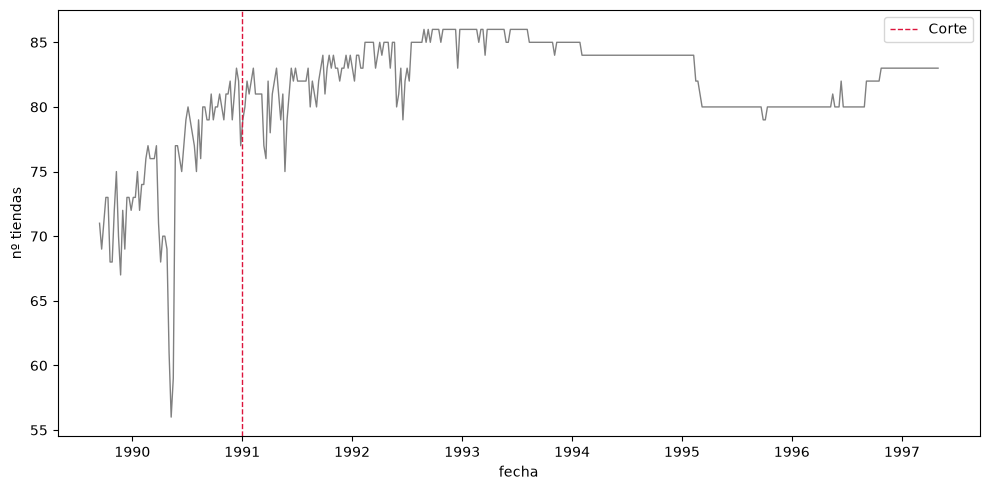

In [11]:
cov = (pepsi.groupby('start')
       .agg(unidades=('MOVE', 'sum'), n_tiendas=('STORE', 'nunique'))
       .reset_index().sort_values('start'))

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(cov['start'], cov['n_tiendas'], lw=1, color='gray')
ax.axvline(pd.Timestamp('1991-01-01'), color='crimson', ls='--', lw=1, label='Corte')
ax.set(xlabel='fecha', ylabel='nº tiendas')

ax.legend()
plt.tight_layout()
plt.show()

Confirmamos visualmente la estabilidad de tiendas.

In [13]:
START = '1991-01-01'  # punto de corte

pepsi_corte = pepsi[pepsi['start'] >= START].copy()

serie = (pepsi_corte.groupby('start')
         .agg(unidades_tot=('MOVE', 'sum'), n_tiendas=('STORE', 'nunique'))
         .reset_index().sort_values('start'))

serie['media_por_tienda'] = serie['unidades_tot'] / serie['n_tiendas']

serie.head()

,start,unidades_tot,n_tiendas,media_por_tienda
0,1991-01-03,14859,79,188.088608
1,1991-01-10,32247,80,403.087500
2,1991-01-17,12822,82,156.365854
3,1991-01-24,12849,81,158.629630
4,1991-01-31,24056,82,293.365854


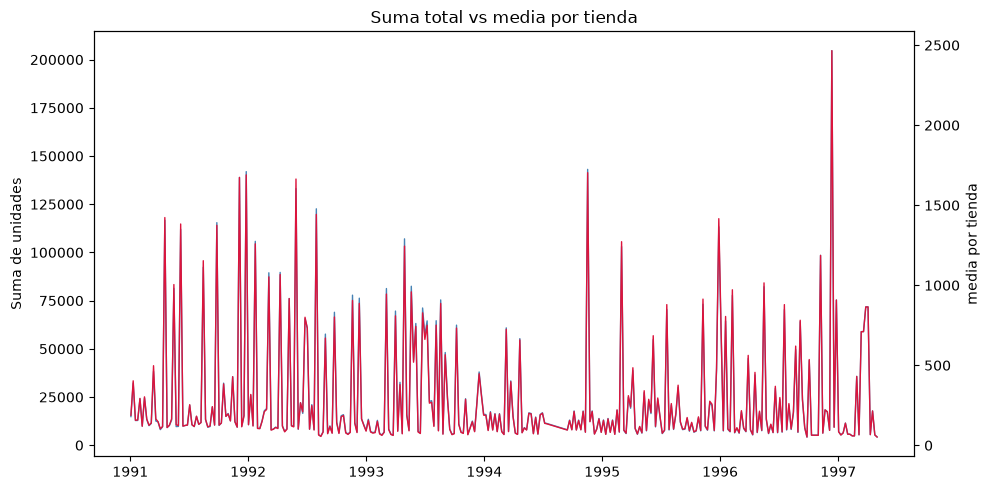

In [22]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(serie["start"], serie["unidades_tot"], color="steelblue", lw=1, label="suma total")
ax1.set(title='Suma total vs media por tienda', ylabel='Suma de unidades')
ax2 = ax1.twinx()
ax2.plot(serie["start"], serie["media_por_tienda"], color="crimson", lw=1, label="media por tienda")
ax2.set_ylabel("media por tienda")

plt.tight_layout()
plt.show()

Como el número de tiendas que reportan ventas no es constante en el tiempo, la suma de unidades confundiría dos cosas: la demanda real y el número de tiendas que la registran. Para evitarlo usamos la media de unidades por tienda, que refleja el nivel de demanda típico por tienda con independencia de cuántas tiendas haya esa semana.

En la práctica, tras recortar el periodo inicial la cobertura es estable, por lo que suma y media por tienda evolucionan casi en paralelo; usamos la media por robustez, aunque en esta ventana la diferencia es menor.

## Construcción de serie única
Para realizar la descomposición `STL`, necesitamos una serie temporal regular y sin espacios vacíos. En esta fase vamos a construir la serie para rellenar los huecos vacios presentes.